In [1]:
import time

from dataclasses import replace
from itertools import product
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from src.config import SimulationConfig
from src.simulator import run_simulation

In [2]:
base_config = SimulationConfig(
    nx=128,
    ny=128,
    max_growth_steps=5000,
)

k_values = [2.0, 5.0, 15.0]
correlation_lengths = [1, 5, 15]
eta_values = [0.5, 1.5, 3.0]
threshold_values = [2.7, 3.0, 3.3]
disorder_seeds = range(10)
random_seeds = range(5)

parameter_grid = list(
    product(
        k_values,
        correlation_lengths,
        eta_values,
        threshold_values,
    )
)

In [3]:
def run_config_block(
    base_config,
    k,
    correlation_length,
    eta,
    mean_breakdown_field,
    disorder_seeds,
    random_seeds,
):
    records = []

    for disorder_seed in disorder_seeds:
        for random_seed in random_seeds:
            config = replace(
                base_config,
                weibull_shape=k,
                correlation_length=correlation_length,
                eta=eta,
                mean_breakdown_field=mean_breakdown_field,
                disorder_seed=disorder_seed,
                random_seed=random_seed,
            )

            field, history, breakdown = run_simulation(config)

            if breakdown:
                status = "breakdown"
            elif len(history) == 0:
                status = "no_start"
            elif len(history) >= config.max_growth_steps:
                status = "max_steps"
            else:
                status = "arrested"

            if np.any(field.channel):
                max_y = int(
                    np.max(
                        np.where(field.channel)[0]
                    )
                )
            else:
                max_y = 0

            height_fraction = (
                max_y / (config.ny - 1)
            )

            records.append(
                {
                    "k": k,
                    "correlation_length": correlation_length,
                    "eta": eta,
                    "mean_breakdown_field": mean_breakdown_field,
                    "disorder_seed": disorder_seed,
                    "random_seed": random_seed,
                    "status": status,
                    "started": status != "no_start",
                    "breakdown": bool(breakdown),
                    "steps": len(history),
                    "max_y": max_y,
                    "height_fraction": height_fraction,
                }
            )

    return records

In [4]:
RESULTS_PATH = Path(
    "joint_parameter_sweep_results.csv"
)

N_JOBS = -1

if RESULTS_PATH.exists():
    print("Loading existing results...")

    results_df = pd.read_csv(
        RESULTS_PATH
    )

else:
    print("Running joint parameter sweep...")

    t0 = time.perf_counter()

    parallel = Parallel(
        n_jobs=N_JOBS,
        backend="loky",
        return_as="generator_unordered",
    )

    tasks = (
        delayed(run_config_block)(
            base_config=base_config,
            k=k,
            correlation_length=correlation_length,
            eta=eta,
            mean_breakdown_field=mean_breakdown_field,
            disorder_seeds=disorder_seeds,
            random_seeds=random_seeds,
        )
        for (
            k,
            correlation_length,
            eta,
            mean_breakdown_field,
        ) in parameter_grid
    )

    blocks = []

    for block in tqdm(
        parallel(tasks),
        total=len(parameter_grid),
        desc="Joint sweep",
        unit="config",
    ):
        blocks.append(block)

    records = [
        record
        for block in blocks
        for record in block
    ]

    results_df = pd.DataFrame(records)

    results_df.to_csv(
        RESULTS_PATH,
        index=False,
    )

    elapsed = time.perf_counter() - t0

    print(
        f"Finished in {elapsed / 60:.2f} min"
    )

print("Shape:", results_df.shape)

results_df.head()

Running joint parameter sweep...


Joint sweep:   0%|          | 0/81 [00:00<?, ?config/s]

Finished in 20.12 min
Shape: (4050, 12)


,k,correlation_length,eta,mean_breakdown_field,disorder_seed,random_seed,status,started,breakdown,steps,max_y,height_fraction
0,2.0,1,3.0,3.3,0,0,arrested,True,False,9,16,0.125984
1,2.0,1,3.0,3.3,0,1,arrested,True,False,9,16,0.125984
2,2.0,1,3.0,3.3,0,2,arrested,True,False,10,16,0.125984
3,2.0,1,3.0,3.3,0,3,arrested,True,False,9,16,0.125984
4,2.0,1,3.0,3.3,0,4,arrested,True,False,9,16,0.125984


In [5]:
parameter_cols = [
    "k",
    "correlation_length",
    "eta",
    "mean_breakdown_field",
]

runs_per_config = (
    results_df
    .groupby(parameter_cols)
    .size()
)

print(
    "Number of physical configurations:",
    len(runs_per_config),
)

print(
    "Runs per configuration:",
    runs_per_config.unique(),
)

print()

print(
    results_df["status"].value_counts()
)

Number of physical configurations: 81
Runs per configuration: [50]

status
breakdown    2191
no_start     1185
arrested      674
Name: count, dtype: int64


In [6]:
config_summary = (
    results_df
    .groupby(parameter_cols)
    .agg(
        n=("breakdown", "size"),
        n_started=("started", "sum"),
        n_breakdown=("breakdown", "sum"),
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
    )
    .reset_index()
)

config_summary[
    "p_breakdown_given_start"
] = (
    config_summary["n_breakdown"]
    / config_summary["n_started"]
)

config_summary.loc[
    config_summary["n_started"] == 0,
    "p_breakdown_given_start",
] = np.nan

config_summary.head()

,k,correlation_length,eta,mean_breakdown_field,n,n_started,n_breakdown,p_start,p_breakdown,p_breakdown_given_start
0,2.0,1,0.5,2.7,50,50,13,1.0,0.26,0.26
1,2.0,1,0.5,3.0,50,50,6,1.0,0.12,0.12
2,2.0,1,0.5,3.3,50,50,2,1.0,0.04,0.04
3,2.0,1,1.5,2.7,50,50,21,1.0,0.42,0.42
4,2.0,1,1.5,3.0,50,50,6,1.0,0.12,0.12


In [7]:
status_counts = (
    results_df
    .groupby(
        parameter_cols + ["status"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

status_counts.head()

status,k,correlation_length,eta,mean_breakdown_field,arrested,breakdown,no_start
0,2.0,1,0.5,2.7,37,13,0
1,2.0,1,0.5,3.0,44,6,0
2,2.0,1,0.5,3.3,48,2,0
3,2.0,1,1.5,2.7,29,21,0
4,2.0,1,1.5,3.0,44,6,0


In [8]:
config_summary = config_summary.merge(
    status_counts,
    on=parameter_cols,
    how="left",
)

for status in [
    "no_start",
    "arrested",
    "breakdown",
    "max_steps",
]:
    if status not in config_summary.columns:
        config_summary[status] = 0

config_summary.head()

,k,correlation_length,eta,mean_breakdown_field,n,n_started,n_breakdown,p_start,p_breakdown,p_breakdown_given_start,arrested,breakdown,no_start,max_steps
0,2.0,1,0.5,2.7,50,50,13,1.0,0.26,0.26,37,13,0,0
1,2.0,1,0.5,3.0,50,50,6,1.0,0.12,0.12,44,6,0,0
2,2.0,1,0.5,3.3,50,50,2,1.0,0.04,0.04,48,2,0,0
3,2.0,1,1.5,2.7,50,50,21,1.0,0.42,0.42,29,21,0,0
4,2.0,1,1.5,3.0,50,50,6,1.0,0.12,0.12,44,6,0,0


In [9]:
config_summary.merge(
    status_counts,
    on=parameter_cols,
)

,k,correlation_length,eta,mean_breakdown_field,n,n_started,n_breakdown,p_start,p_breakdown,p_breakdown_given_start,arrested_x,breakdown_x,no_start_x,max_steps,arrested_y,breakdown_y,no_start_y
0,2.0,1,0.5,2.7,50,50,13,1.0,0.26,0.26,37,13,0,0,37,13,0
1,2.0,1,0.5,3.0,50,50,6,1.0,0.12,0.12,44,6,0,0,44,6,0
2,2.0,1,0.5,3.3,50,50,2,1.0,0.04,0.04,48,2,0,0,48,2,0
3,2.0,1,1.5,2.7,50,50,21,1.0,0.42,0.42,29,21,0,0,29,21,0
4,2.0,1,1.5,3.0,50,50,6,1.0,0.12,0.12,44,6,0,0,44,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,15.0,15,1.5,3.0,50,30,30,0.6,0.60,1.00,0,30,20,0,0,30,20
77,15.0,15,1.5,3.3,50,0,0,0.0,0.00,NaN,0,0,50,0,0,0,50
78,15.0,15,3.0,2.7,50,50,50,1.0,1.00,1.00,0,50,0,0,0,50,0
79,15.0,15,3.0,3.0,50,30,30,0.6,0.60,1.00,0,30,20,0,0,30,20


In [10]:
config_summary[
    [
        "k",
        "correlation_length",
        "eta",
        "mean_breakdown_field",
        "p_start",
        "p_breakdown",
        "p_breakdown_given_start",
        "no_start",
        "arrested",
        "breakdown",
    ]
].head(12)

,k,correlation_length,eta,mean_breakdown_field,p_start,p_breakdown,p_breakdown_given_start,no_start,arrested,breakdown
0,2.0,1,0.5,2.7,1.0,0.26,0.260000,0,37,13
1,2.0,1,0.5,3.0,1.0,0.12,0.120000,0,44,6
2,2.0,1,0.5,3.3,1.0,0.04,0.040000,0,48,2
3,2.0,1,1.5,2.7,1.0,0.42,0.420000,0,29,21
4,2.0,1,1.5,3.0,1.0,0.12,0.120000,0,44,6
5,2.0,1,1.5,3.3,1.0,0.02,0.020000,0,49,1
6,2.0,1,3.0,2.7,1.0,0.32,0.320000,0,34,16
7,2.0,1,3.0,3.0,1.0,0.02,0.020000,0,49,1
8,2.0,1,3.0,3.3,1.0,0.02,0.020000,0,49,1
9,2.0,5,0.5,2.7,0.7,0.64,0.914286,15,3,32


In [11]:
k_ebd_summary = (
    results_df
    .groupby(
        [
            "k",
            "mean_breakdown_field",
        ]
    )
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        n_started=("started", "sum"),
        n_breakdown=("breakdown", "sum"),
    )
    .reset_index()
)

k_ebd_summary[
    "p_breakdown_given_start"
] = (
    k_ebd_summary["n_breakdown"]
    / k_ebd_summary["n_started"]
)

k_ebd_summary

,k,mean_breakdown_field,p_start,p_breakdown,n_started,n_breakdown,p_breakdown_given_start
0,2.0,2.7,0.900000,0.651111,405,293,0.723457
1,2.0,3.0,0.900000,0.526667,405,237,0.585185
2,2.0,3.3,0.866667,0.431111,390,194,0.497436
3,5.0,2.7,0.866667,0.782222,390,352,0.902564
4,5.0,3.0,0.733333,0.533333,330,240,0.727273
5,5.0,3.3,0.500000,0.364444,225,164,0.728889
6,15.0,2.7,1.000000,1.000000,450,450,1.000000
7,15.0,3.0,0.533333,0.533333,240,240,1.000000
8,15.0,3.3,0.066667,0.046667,30,21,0.700000


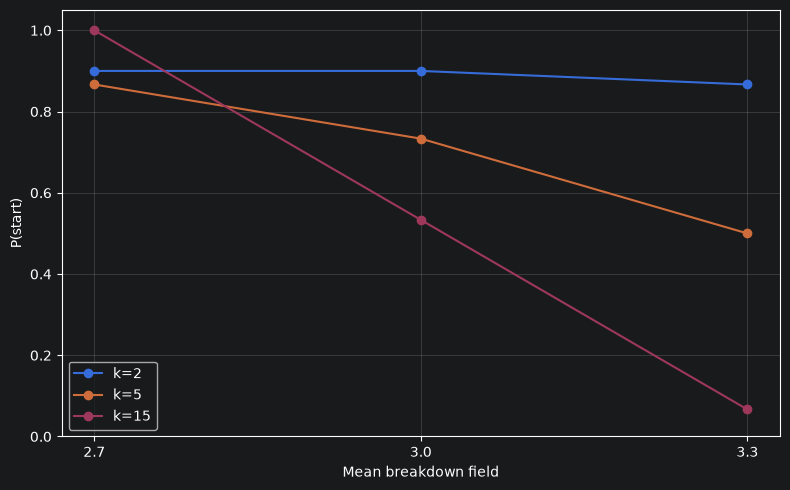

In [12]:
plt.figure(figsize=(8, 5))

for k in k_values:
    subset = k_ebd_summary[
        k_ebd_summary["k"] == k
    ]

    plt.plot(
        subset["mean_breakdown_field"],
        subset["p_start"],
        marker="o",
        label=f"k={k:g}",
    )

plt.xlabel("Mean breakdown field")
plt.ylabel("P(start)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие Weibull shape и порога пробоя

Совместный sweep показывает выраженное взаимодействие между `weibull_shape` и `mean_breakdown_field`.

При малом

$$
k=2
$$

вероятность старта почти не меняется при увеличении порога:

$$
P(start)\approx0.90,\ 0.90,\ 0.87.
$$

Напротив, при

$$
k=15
$$

вероятность старта резко падает:

$$
1.00 \rightarrow 0.53 \rightarrow 0.07.
$$

Следовательно, влияние базового порога пробоя на инициацию зависит от степени неоднородности материала.

В сильно неоднородной среде экстремально слабые области сохраняют возможность старта даже при повышенном пороге, тогда как в более однородной среде увеличение порога быстро подавляет возникновение канала.

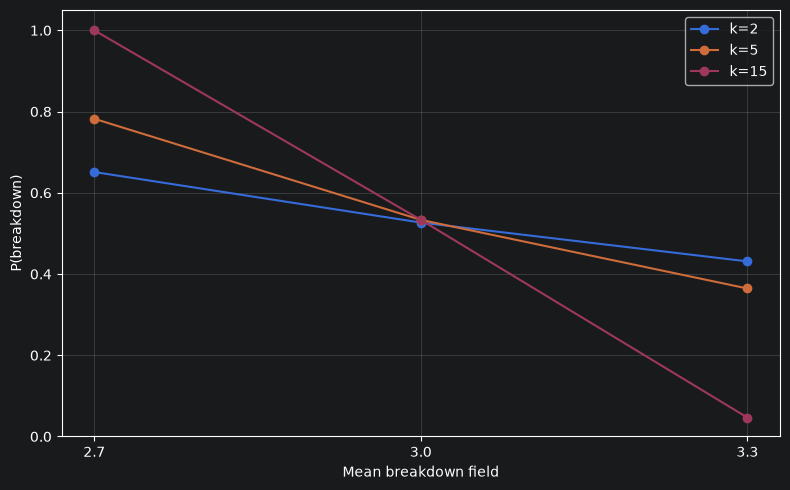

In [13]:
plt.figure(figsize=(8, 5))

for k in k_values:
    subset = k_ebd_summary[
        k_ebd_summary["k"] == k
    ]

    plt.plot(
        subset["mean_breakdown_field"],
        subset["p_breakdown"],
        marker="o",
        label=f"k={k:g}",
    )

plt.xlabel("Mean breakdown field")
plt.ylabel("P(breakdown)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие параметров при полном пробое

Зависимость полной вероятности пробоя также показывает сильное взаимодействие между $k$ и $E_{bd}$.

При низком пороге

$$
E_{bd}=2.7
$$

вероятность пробоя возрастает с увеличением $k$.

Однако при высоком пороге

$$
E_{bd}=3.3
$$

наблюдается противоположная картина: наиболее однородная среда с

$$
k=15
$$

практически перестаёт пробиваться.

Особенно интересно, что около

$$
E_{bd}=3.0
$$

вероятности полного пробоя для разных $k$ практически совпадают.

Это указывает на наличие переходной области, в которой влияние неоднородности меняет характер.

Таким образом, параметры $k$ и $E_{bd}$ нельзя рассматривать независимо: изменение порога пробоя качественно меняет влияние неоднородности материала на итоговый исход.

In [14]:
xi_ebd_summary = (
    results_df
    .groupby(
        [
            "correlation_length",
            "mean_breakdown_field",
        ]
    )
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        n_started=("started", "sum"),
        n_breakdown=("breakdown", "sum"),
    )
    .reset_index()
)

xi_ebd_summary[
    "p_breakdown_given_start"
] = (
    xi_ebd_summary["n_breakdown"]
    / xi_ebd_summary["n_started"]
)

xi_ebd_summary

,correlation_length,mean_breakdown_field,p_start,p_breakdown,n_started,n_breakdown,p_breakdown_given_start
0,1,2.7,0.966667,0.660000,435,297,0.682759
1,1,3.0,0.766667,0.295556,345,133,0.385507
2,1,3.3,0.533333,0.053333,240,24,0.100000
3,5,2.7,0.800000,0.773333,360,348,0.966667
4,5,3.0,0.600000,0.497778,270,224,0.829630
5,5,3.3,0.400000,0.322222,180,145,0.805556
6,15,2.7,1.000000,1.000000,450,450,1.000000
7,15,3.0,0.800000,0.800000,360,360,1.000000
8,15,3.3,0.500000,0.466667,225,210,0.933333


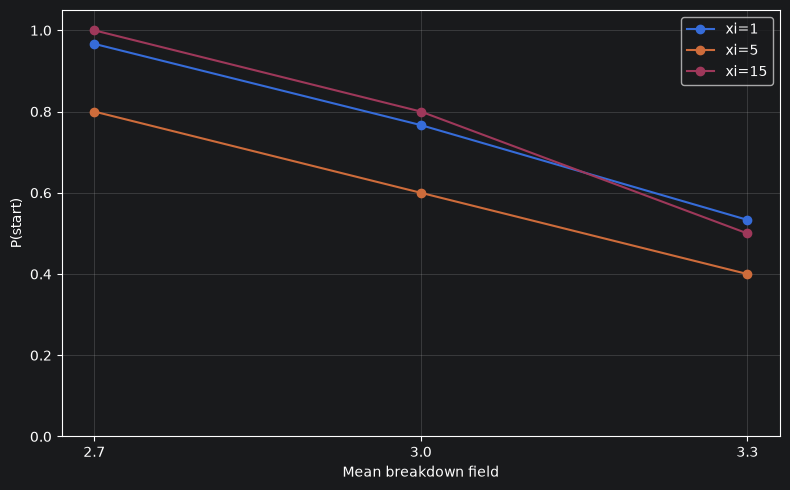

In [15]:
plt.figure(figsize=(8, 5))

for xi in correlation_lengths:
    subset = xi_ebd_summary[
        xi_ebd_summary[
            "correlation_length"
        ] == xi
    ]

    plt.plot(
        subset["mean_breakdown_field"],
        subset["p_start"],
        marker="o",
        label=f"xi={xi}",
    )

plt.xlabel("Mean breakdown field")
plt.ylabel("P(start)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Влияние correlation length на старт

В joint sweep параметр `correlation_length` начинает проявлять влияние и на вероятность старта.

При этом зависимость не является монотонной: промежуточное значение

$$
\xi=5
$$

даёт меньшую вероятность старта, чем как более мелкая, так и более крупная пространственная неоднородность.

Это отличается от однофакторного эксперимента, где значимого влияния $\xi$ на старт обнаружено не было. Различие указывает на взаимодействие `correlation_length` с другими физическими параметрами, прежде всего с $k$ и $E_{bd}$.

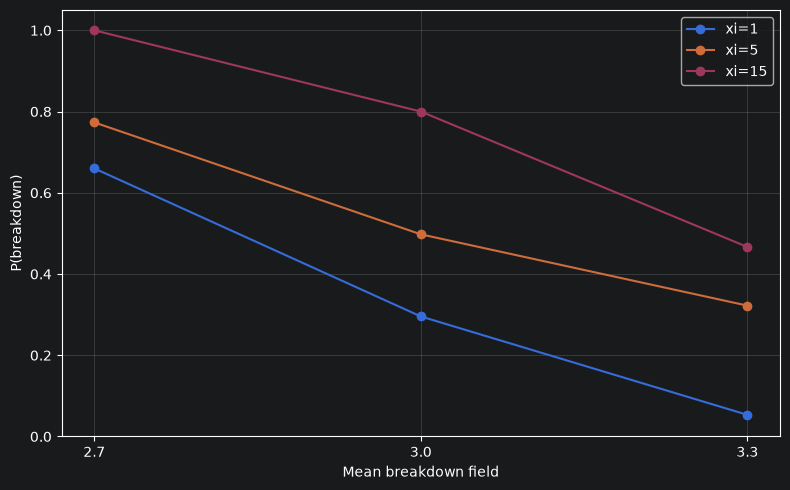

In [16]:
plt.figure(figsize=(8, 5))

for xi in correlation_lengths:
    subset = xi_ebd_summary[
        xi_ebd_summary[
            "correlation_length"
        ] == xi
    ]

    plt.plot(
        subset["mean_breakdown_field"],
        subset["p_breakdown"],
        marker="o",
        label=f"xi={xi}",
    )

plt.xlabel("Mean breakdown field")
plt.ylabel("P(breakdown)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Влияние correlation length на полный пробой

Вероятность полного пробоя монотонно возрастает с увеличением `correlation_length`.

При

$$
\xi=1
$$

вероятность полного пробоя резко падает с ростом порога:

$$
0.66 \rightarrow 0.30 \rightarrow 0.05.
$$

Для

$$
\xi=15
$$

она остаётся существенно выше:

$$
1.00 \rightarrow 0.80 \rightarrow 0.46.
$$

Следовательно, крупномасштабная пространственная корреляция неоднородности существенно облегчает распространение пробоя через материал.

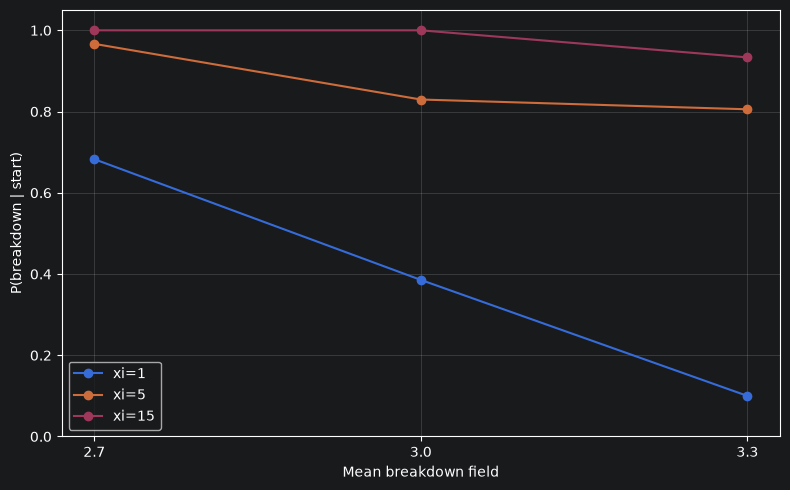

In [17]:
plt.figure(figsize=(8, 5))

for xi in correlation_lengths:
    subset = xi_ebd_summary[
        xi_ebd_summary[
            "correlation_length"
        ] == xi
    ]

    plt.plot(
        subset["mean_breakdown_field"],
        subset["p_breakdown_given_start"],
        marker="o",
        label=f"xi={xi}",
    )

plt.xlabel("Mean breakdown field")
plt.ylabel("P(breakdown | start)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Влияние correlation length на распространение после старта

Наиболее сильный эффект `correlation_length` наблюдается для условной вероятности

$$
P(breakdown \mid start).
$$

При мелком disorder,

$$
\xi=1,
$$

вероятность успешного распространения стартовавшего канала уменьшается примерно

$$
0.68 \rightarrow 0.10
$$

при увеличении порога.

Напротив, при

$$
\xi=15
$$

стартовавший канал почти всегда приводит к полному пробою:

$$
P(breakdown \mid start) \approx 0.93-1.00.
$$

Это подтверждает физическую интерпретацию `correlation_length` как параметра пространственной связности слабых областей.

При малом $\xi$ канал встречает большое число мелких сильных барьеров, тогда как при большом $\xi$ слабые области образуют протяжённые связные регионы, способные поддерживать дальнейший рост.

In [18]:
eta_ebd_summary = (
    results_df
    .groupby(
        [
            "eta",
            "mean_breakdown_field",
        ]
    )
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        n_started=("started", "sum"),
        n_breakdown=("breakdown", "sum"),
    )
    .reset_index()
)

eta_ebd_summary[
    "p_breakdown_given_start"
] = (
    eta_ebd_summary["n_breakdown"]
    / eta_ebd_summary["n_started"]
)

eta_ebd_summary

,eta,mean_breakdown_field,p_start,p_breakdown,n_started,n_breakdown,p_breakdown_given_start
0,0.5,2.7,0.922222,0.804444,415,362,0.872289
1,0.5,3.0,0.722222,0.537778,325,242,0.744615
2,0.5,3.3,0.477778,0.280000,215,126,0.586047
3,1.5,2.7,0.922222,0.815556,415,367,0.884337
4,1.5,3.0,0.722222,0.531111,325,239,0.735385
5,1.5,3.3,0.477778,0.280000,215,126,0.586047
6,3.0,2.7,0.922222,0.813333,415,366,0.881928
7,3.0,3.0,0.722222,0.524444,325,236,0.726154
8,3.0,3.3,0.477778,0.282222,215,127,0.590698


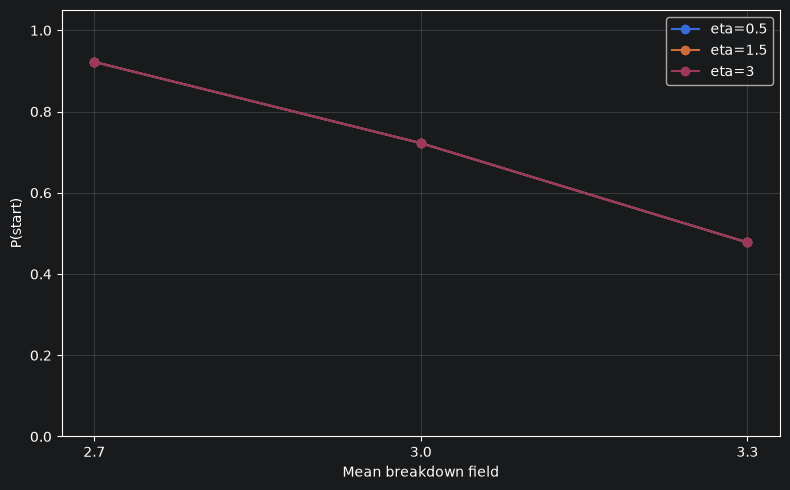

In [19]:
plt.figure(figsize=(8, 5))

for eta in eta_values:
    subset = eta_ebd_summary[
        eta_ebd_summary["eta"] == eta
    ]

    plt.plot(
        subset["mean_breakdown_field"],
        subset["p_start"],
        marker="o",
        label=f"eta={eta:g}",
    )

plt.xlabel("Mean breakdown field")
plt.ylabel("P(start)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Влияние eta на вероятность старта

В joint sweep вероятность старта полностью совпадает для всех исследованных значений `eta`.

Например,

$$
P(start)=0.922,\ 0.722,\ 0.478
$$

при

$$
E_{bd}=2.7,\ 3.0,\ 3.3
$$

соответственно, независимо от `eta`.

Таким образом, даже при совместном изменении параметров среды `eta` не влияет на инициацию канала.

Это согласуется со структурой модели: `eta` определяет относительные вероятности выбора уже активных клеток,

$$
P_i \propto d_i^\eta,
$$

но не входит в условие существования активной клетки.

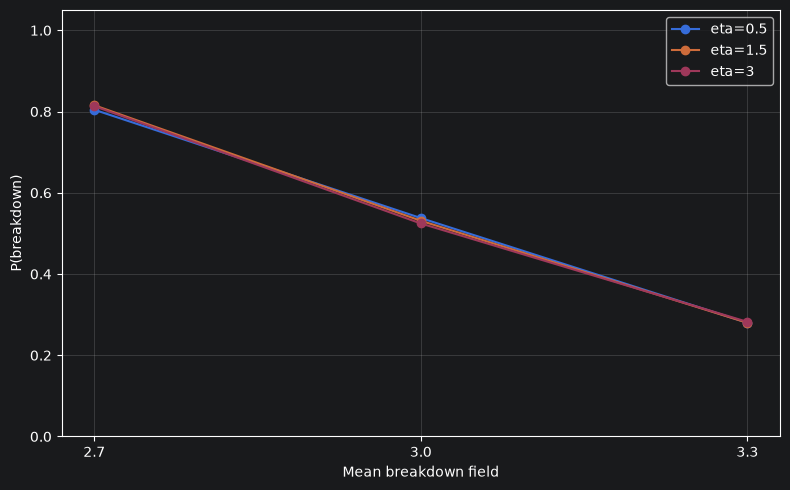

In [20]:
plt.figure(figsize=(8, 5))

for eta in eta_values:
    subset = eta_ebd_summary[
        eta_ebd_summary["eta"] == eta
    ]

    plt.plot(
        subset["mean_breakdown_field"],
        subset["p_breakdown"],
        marker="o",
        label=f"eta={eta:g}",
    )

plt.xlabel("Mean breakdown field")
plt.ylabel("P(breakdown)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Влияние eta на вероятность полного пробоя

Вероятность полного пробоя практически не меняется при изменении `eta`.

Для каждого значения порога линии почти полностью совпадают. Различия составляют лишь несколько процентных пунктов и не демонстрируют систематического тренда.

Следовательно, в исследованном пространстве параметров `eta` остаётся слабым параметром макроскопического исхода.

Его основная роль связана не с вероятностью полного пробоя, а с выбором конкретной траектории роста.

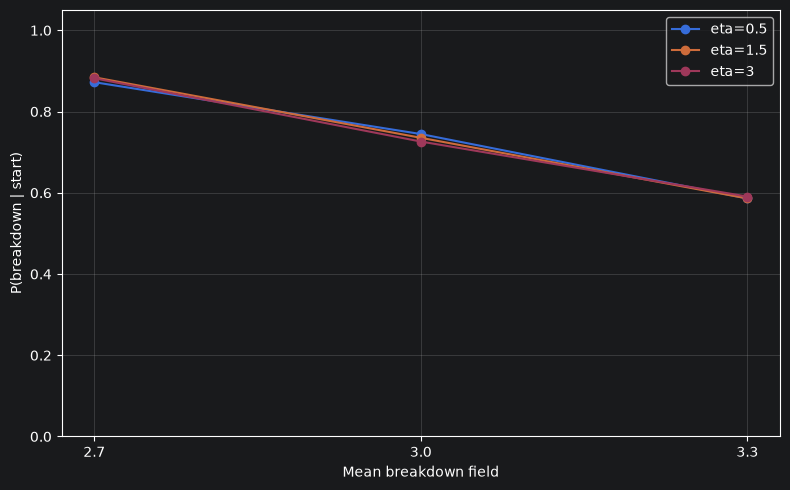

In [21]:
plt.figure(figsize=(8, 5))

for eta in eta_values:
    subset = eta_ebd_summary[
        eta_ebd_summary["eta"] == eta
    ]

    plt.plot(
        subset["mean_breakdown_field"],
        subset["p_breakdown_given_start"],
        marker="o",
        label=f"eta={eta:g}",
    )

plt.xlabel("Mean breakdown field")
plt.ylabel("P(breakdown | start)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Влияние eta на распространение после старта

Условная вероятность

$$
P(breakdown \mid start)
$$

также практически не зависит от `eta`.

Даже при изменении порога и других параметров среды различия между значениями `eta` остаются малы.

Таким образом, селективность стохастического выбора пути почти не изменяет вероятность того, что стартовавший канал завершится полным пробоем.

Это дополнительно подтверждает, что `eta` следует интерпретировать прежде всего как параметр геометрии и кинетики роста.

In [22]:
eta_steps = (
    results_df[
        results_df["started"]
    ]
    .groupby("eta")
    .agg(
        n=("steps", "size"),
        mean_steps=("steps", "mean"),
        median_steps=("steps", "median"),
        std_steps=("steps", "std"),
    )
)

eta_steps

,n,mean_steps,median_steps,std_steps
eta,,,,
0.5,955,613.780105,722.0,361.612348
1.5,955,281.747644,314.0,168.187826
3.0,955,177.308901,201.0,103.147174


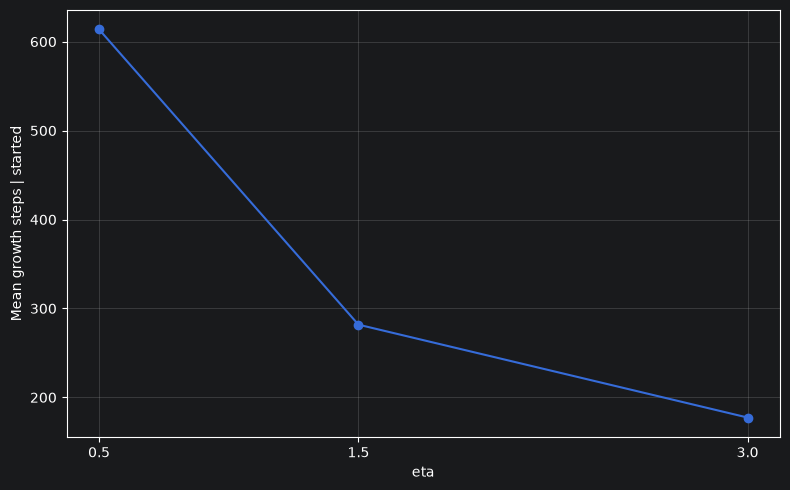

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    eta_steps.index,
    eta_steps["mean_steps"],
    marker="o",
)

plt.xlabel("eta")
plt.ylabel("Mean growth steps | started")
plt.xticks(eta_values)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Влияние eta на динамику роста

В отличие от вероятностей исхода, число шагов очень сильно зависит от `eta`.

Среднее число шагов среди стартовавших траекторий уменьшается:

$$
614 \rightarrow 282 \rightarrow 177
$$

при изменении

$$
\eta: 0.5 \rightarrow 1.5 \rightarrow 3.0.
$$

Медиана демонстрирует тот же эффект:

$$
722 \rightarrow 314 \rightarrow 201.
$$

Следовательно, результат однофакторного анализа полностью сохраняется в совместном пространстве параметров.

Увеличение `eta` делает выбор следующей клетки более селективным, поэтому канал сильнее предпочитает направления с максимальным локальным drive и достигает конечного состояния значительно меньшим числом шагов.

In [25]:
step_index = [
    "k",
    "correlation_length",
    "mean_breakdown_field",
    "disorder_seed",
    "random_seed",
]

steps_pivot = (
    results_df[
        results_df["started"]
    ]
    .pivot(
        index=step_index,
        columns="eta",
        values="steps",
    )
    .dropna()
)

print(
    "Matched trajectories:",
    len(steps_pivot),
)

steps_pivot.head()

Matched trajectories: 955


eta                                                                    0.5  \
k   correlation_length mean_breakdown_field disorder_seed random_seed        
2.0 1                  2.7                  0             0             55   
                                                          1             59   
                                                          2            839   
                                                          3             56   
                                                          4             50   

eta                                                                    1.5  \
k   correlation_length mean_breakdown_field disorder_seed random_seed        
2.0 1                  2.7                  0             0             51   
                                                          1            486   
                                                          2             45   
                                                          3            376   
                                                          4             47   

eta                                                                    3.0  
k   correlation_length mean_breakdown_field disorder_seed random_seed       
2.0 1                  2.7                  0             0             45  
                                                          1            298  
                                                          2             43  
                                                          3            273  
                                                          4             44

In [26]:
from scipy.stats import friedmanchisquare

stat, p_value = friedmanchisquare(
    *[
        steps_pivot[eta].values
        for eta in eta_values
    ]
)

kendall_w = (
    stat
    / (
        len(steps_pivot)
        * (len(eta_values) - 1)
    )
)

print("Friedman statistic:", stat)
print("p-value:", p_value)
print("Kendall W:", kendall_w)

Friedman statistic: 1428.456886227546
p-value: 6.5242160955285e-311
Kendall W: 0.7478831865065686


### Статистическая проверка влияния eta на число шагов

Для сравнения использовались 955 сопоставленных траекторий, для которых были доступны результаты при всех трёх значениях `eta`.

Критерий Фридмана дал:

$$
\chi_F^2 \approx 1428.46,
$$

$$
p \approx 6.52 \times 10^{-311}.
$$

Размер эффекта по Kendall's W:

$$
W \approx 0.748.
$$

Это соответствует очень сильному эффекту.

Таким образом, параметр `eta` оказывает выраженное и устойчивое влияние на кинетику роста во всём исследованном пространстве физических параметров.

При этом ранее было показано, что `eta` практически не влияет на вероятность старта и полного пробоя.

Следовательно, `eta` следует интерпретировать прежде всего как параметр выбора траектории и геометрии роста, а не как параметр макроскопического исхода.

In [27]:
k_xi_summary = (
    results_df
    .groupby(
        [
            "k",
            "correlation_length",
        ]
    )
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        n_started=("started", "sum"),
        n_breakdown=("breakdown", "sum"),
    )
    .reset_index()
)

k_xi_summary[
    "p_breakdown_given_start"
] = (
    k_xi_summary["n_breakdown"]
    / k_xi_summary["n_started"]
)

k_xi_summary

,k,correlation_length,p_start,p_breakdown,n_started,n_breakdown,p_breakdown_given_start
0,2.0,1,1.000000,0.148889,450,67,0.148889
1,2.0,5,0.700000,0.526667,315,237,0.752381
2,2.0,15,0.966667,0.933333,435,420,0.965517
3,5.0,1,0.700000,0.313333,315,141,0.447619
4,5.0,5,0.600000,0.566667,270,255,0.944444
5,5.0,15,0.800000,0.800000,360,360,1.000000
6,15.0,1,0.566667,0.546667,255,246,0.964706
7,15.0,5,0.500000,0.500000,225,225,1.000000
8,15.0,15,0.533333,0.533333,240,240,1.000000


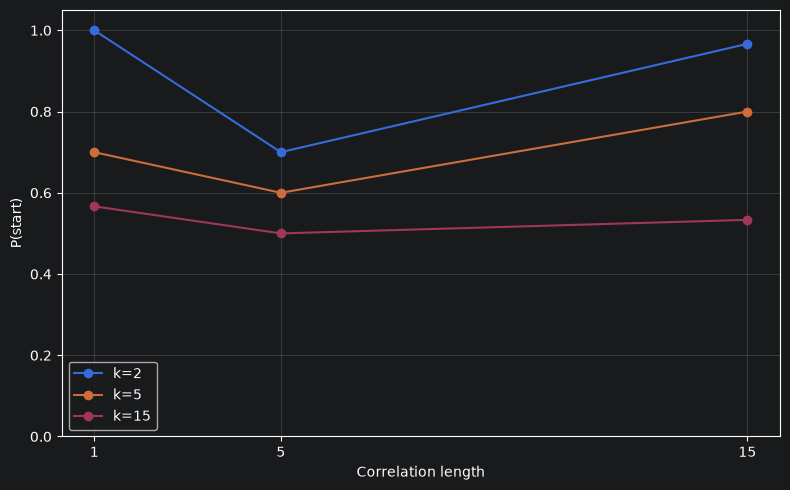

In [29]:
plt.figure(figsize=(8, 5))

for k in k_values:
    subset = k_xi_summary[
        k_xi_summary["k"] == k
    ]

    plt.plot(
        subset["correlation_length"],
        subset["p_start"],
        marker="o",
        label=f"k={k:g}",
    )

plt.xlabel("Correlation length")
plt.ylabel("P(start)")
plt.xticks(correlation_lengths)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие k и correlation length: вероятность старта

Вероятность старта зависит от совместного значения `weibull_shape` и `correlation_length`.

При сильной неоднородности

$$
k=2
$$

изменение пространственного масштаба disorder существенно меняет вероятность старта, причём зависимость является немонотонной.

Напротив, при

$$
k=15
$$

вероятность старта остаётся близкой к

$$
0.5
$$

для всех исследованных correlation lengths.

Таким образом, влияние пространственной структуры неоднородности на инициацию особенно заметно в материалах с большим разбросом локальной прочности.

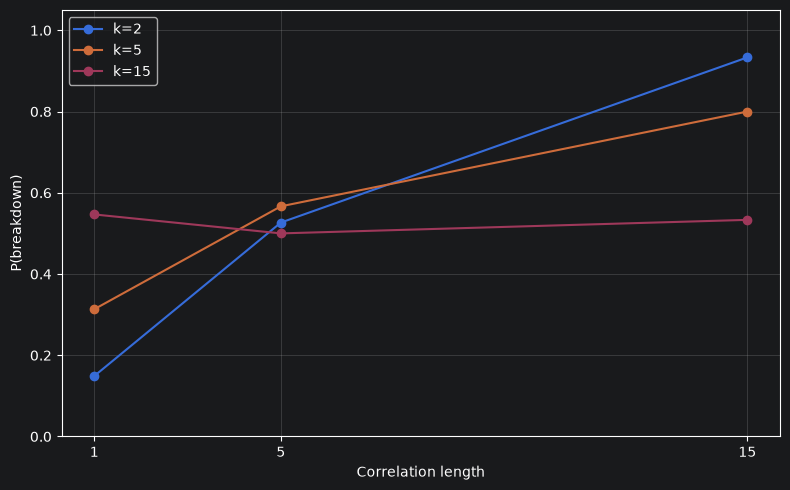

In [30]:
plt.figure(figsize=(8, 5))

for k in k_values:
    subset = k_xi_summary[
        k_xi_summary["k"] == k
    ]

    plt.plot(
        subset["correlation_length"],
        subset["p_breakdown"],
        marker="o",
        label=f"k={k:g}",
    )

plt.xlabel("Correlation length")
plt.ylabel("P(breakdown)")
plt.xticks(correlation_lengths)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие k и correlation length: полный пробой

Для вероятности полного пробоя наблюдается выраженное взаимодействие между $k$ и $\xi$.

При малой correlation length

$$
\xi=1
$$

увеличение $k$ повышает вероятность полного пробоя.

Однако при большой correlation length

$$
\xi=15
$$

наблюдается противоположная картина: наибольшая вероятность пробоя возникает при малом $k$.

Таким образом, эффект Weibull shape меняет характер в зависимости от пространственного масштаба неоднородности.

Это означает, что амплитуду disorder и его пространственную структуру нельзя рассматривать как независимые факторы.

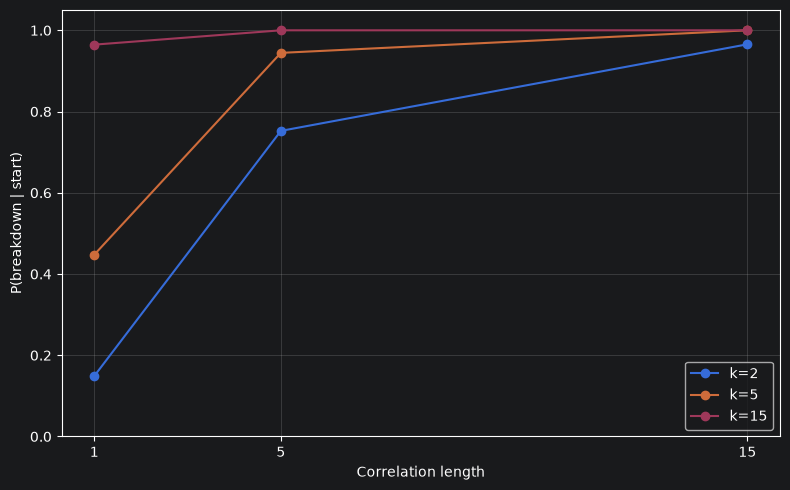

In [31]:
plt.figure(figsize=(8, 5))

for k in k_values:
    subset = k_xi_summary[
        k_xi_summary["k"] == k
    ]

    plt.plot(
        subset["correlation_length"],
        subset["p_breakdown_given_start"],
        marker="o",
        label=f"k={k:g}",
    )

plt.xlabel("Correlation length")
plt.ylabel("P(breakdown | start)")
plt.xticks(correlation_lengths)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие k и correlation length: распространение после старта

Наиболее наглядное взаимодействие наблюдается для

$$
P(breakdown \mid start).
$$

При

$$
k=2,\qquad \xi=1
$$

лишь небольшая доля стартовавших каналов приводит к полному пробою.

Однако при увеличении correlation length вероятность успешного распространения резко возрастает и при

$$
\xi=15
$$

становится близкой к единице.

При большом

$$
k=15
$$

условная вероятность пробоя остаётся высокой почти независимо от $\xi$.

Физически это означает, что при сильной неоднородности результат определяется не только амплитудой вариаций прочности, но и пространственной связностью слабых областей.

Мелкомасштабная неоднородность создаёт большое число локальных барьеров, тогда как крупномасштабная корреляция может формировать протяжённые слабые пути через материал.

In [32]:
k_eta_summary = (
    results_df
    .groupby(
        [
            "k",
            "eta",
        ]
    )
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        n_started=("started", "sum"),
        n_breakdown=("breakdown", "sum"),
    )
    .reset_index()
)

k_eta_summary[
    "p_breakdown_given_start"
] = (
    k_eta_summary["n_breakdown"]
    / k_eta_summary["n_started"]
)

k_eta_summary

,k,eta,p_start,p_breakdown,n_started,n_breakdown,p_breakdown_given_start
0,2.0,0.5,0.888889,0.535556,400,241,0.602500
1,2.0,1.5,0.888889,0.544444,400,245,0.612500
2,2.0,3.0,0.888889,0.528889,400,238,0.595000
3,5.0,0.5,0.700000,0.560000,315,252,0.800000
4,5.0,1.5,0.700000,0.557778,315,251,0.796825
5,5.0,3.0,0.700000,0.562222,315,253,0.803175
6,15.0,0.5,0.533333,0.526667,240,237,0.987500
7,15.0,1.5,0.533333,0.524444,240,236,0.983333
8,15.0,3.0,0.533333,0.528889,240,238,0.991667


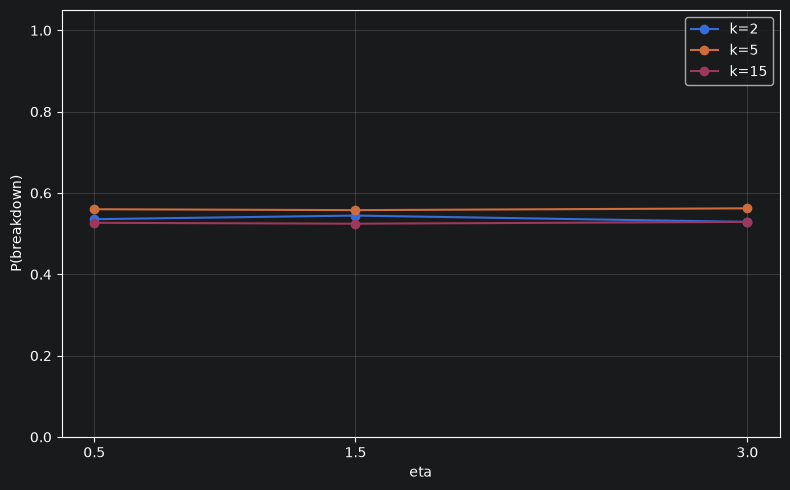

In [33]:
plt.figure(figsize=(8, 5))

for k in k_values:
    subset = k_eta_summary[
        k_eta_summary["k"] == k
    ]

    plt.plot(
        subset["eta"],
        subset["p_breakdown"],
        marker="o",
        label=f"k={k:g}",
    )

plt.xlabel("eta")
plt.ylabel("P(breakdown)")
plt.xticks(eta_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие k и eta: вероятность полного пробоя

Вероятность полного пробоя практически не меняется при изменении `eta` для всех исследованных значений `k`.

Линии для

$$
k=2,\quad k=5,\quad k=15
$$

почти горизонтальны и близки друг к другу.

Следовательно, заметного взаимодействия

$$
k \times \eta
$$

на уровне макроскопического исхода не наблюдается.

Это подтверждает предыдущий результат: параметр `eta` практически не управляет вероятностью полного пробоя даже при различной степени неоднородности материала.

In [34]:
k_eta_steps = (
    results_df[
        results_df["started"]
    ]
    .groupby(
        [
            "k",
            "eta",
        ]
    )
    .agg(
        n=("steps", "size"),
        mean_steps=("steps", "mean"),
        median_steps=("steps", "median"),
    )
    .reset_index()
)

k_eta_steps

,k,eta,n,mean_steps,median_steps
0,2.0,0.5,400,563.952500,770.0
1,2.0,1.5,400,274.642500,350.0
2,2.0,3.0,400,172.295000,220.0
3,5.0,0.5,315,597.073016,709.0
4,5.0,1.5,315,264.536508,299.0
5,5.0,3.0,315,169.634921,201.0
6,15.0,0.5,240,718.754167,727.0
7,15.0,1.5,240,316.179167,316.0
8,15.0,3.0,240,195.737500,199.0


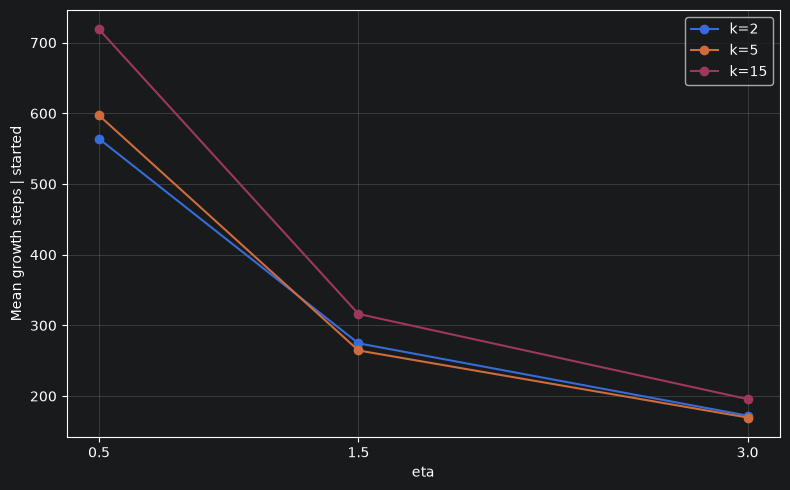

In [35]:
plt.figure(figsize=(8, 5))

for k in k_values:
    subset = k_eta_steps[
        k_eta_steps["k"] == k
    ]

    plt.plot(
        subset["eta"],
        subset["mean_steps"],
        marker="o",
        label=f"k={k:g}",
    )

plt.xlabel("eta")
plt.ylabel("Mean growth steps | started")
plt.xticks(eta_values)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие k и eta: кинетика роста

В отличие от вероятности полного пробоя, число шагов сильно зависит от `eta` при всех значениях `k`.

При увеличении

$$
\eta: 0.5 \rightarrow 3.0
$$

среднее число шагов уменьшается примерно в 3–4 раза.

Дополнительно наблюдается взаимодействие с `weibull_shape`.

При малом

$$
\eta=0.5
$$

различия между материалами с разными `k` выражены сильнее: при большом `k` канал в среднем требует заметно больше шагов.

При

$$
\eta=3
$$

линии сближаются, и влияние `k` на число шагов становится значительно слабее.

Таким образом, высокая селективность роста частично подавляет влияние амплитуды неоднородности на кинетику: канал преимущественно выбирает клетки с максимальным локальным drive независимо от более тонких различий в распределении прочности.

In [36]:
xi_eta_summary = (
    results_df
    .groupby(
        [
            "correlation_length",
            "eta",
        ]
    )
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        n_started=("started", "sum"),
        n_breakdown=("breakdown", "sum"),
    )
    .reset_index()
)

xi_eta_summary[
    "p_breakdown_given_start"
] = (
    xi_eta_summary["n_breakdown"]
    / xi_eta_summary["n_started"]
)

xi_eta_summary

,correlation_length,eta,p_start,p_breakdown,n_started,n_breakdown,p_breakdown_given_start
0,1,0.5,0.755556,0.333333,340,150,0.441176
1,1,1.5,0.755556,0.344444,340,155,0.455882
2,1,3.0,0.755556,0.331111,340,149,0.438235
3,5,0.5,0.600000,0.533333,270,240,0.888889
4,5,1.5,0.600000,0.526667,270,237,0.877778
5,5,3.0,0.600000,0.533333,270,240,0.888889
6,15,0.5,0.766667,0.755556,345,340,0.985507
7,15,1.5,0.766667,0.755556,345,340,0.985507
8,15,3.0,0.766667,0.755556,345,340,0.985507


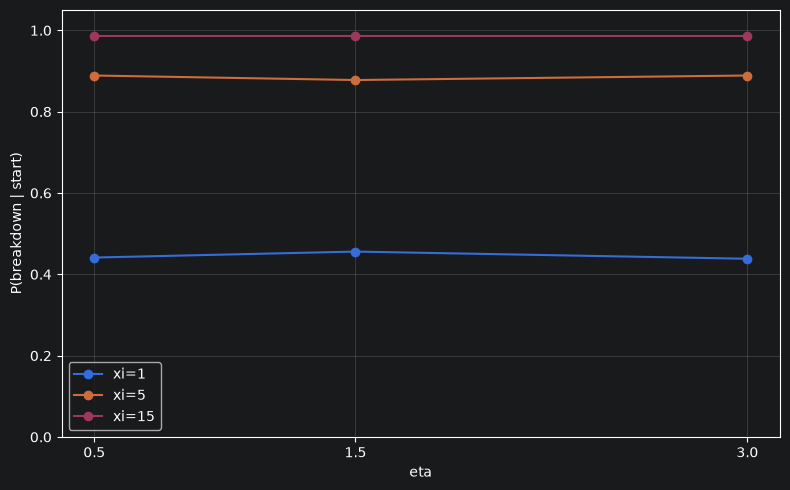

In [37]:
plt.figure(figsize=(8, 5))

for xi in correlation_lengths:
    subset = xi_eta_summary[
        xi_eta_summary[
            "correlation_length"
        ] == xi
    ]

    plt.plot(
        subset["eta"],
        subset["p_breakdown_given_start"],
        marker="o",
        label=f"xi={xi}",
    )

plt.xlabel("eta")
plt.ylabel("P(breakdown | start)")
plt.xticks(eta_values)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие correlation length и eta: вероятность пробоя после старта

Для каждого фиксированного значения `correlation_length` условная вероятность

$$
P(breakdown \mid start)
$$

практически не меняется при изменении `eta`.

При этом различия между разными correlation lengths остаются очень сильными:

$$
P(breakdown \mid start) \approx 0.44
$$

для

$$
\xi=1,
$$

около

$$
0.89
$$

для

$$
\xi=5,
$$

и практически единица для

$$
\xi=15.
$$

Следовательно, выраженного взаимодействия $\xi\times\eta$ на уровне макроскопического исхода не наблюдается.

Параметр $\xi$ определяет устойчивость распространения канала, тогда как `eta` почти не изменяет вероятность успешного пробоя уже после старта.

In [38]:
xi_eta_steps = (
    results_df[
        results_df["started"]
    ]
    .groupby(
        [
            "correlation_length",
            "eta",
        ]
    )
    .agg(
        n=("steps", "size"),
        mean_steps=("steps", "mean"),
        median_steps=("steps", "median"),
    )
    .reset_index()
)

xi_eta_steps

,correlation_length,eta,n,mean_steps,median_steps
0,1,0.5,340,335.682353,48.5
1,1,1.5,340,161.035294,30.5
2,1,3.0,340,102.902941,26.0
3,5,0.5,270,725.129630,782.0
4,5,1.5,270,342.107407,350.5
5,5,3.0,270,226.018519,213.0
6,15,0.5,345,800.704348,788.0
7,15,1.5,345,353.472464,342.0
8,15,3.0,345,212.515942,206.0


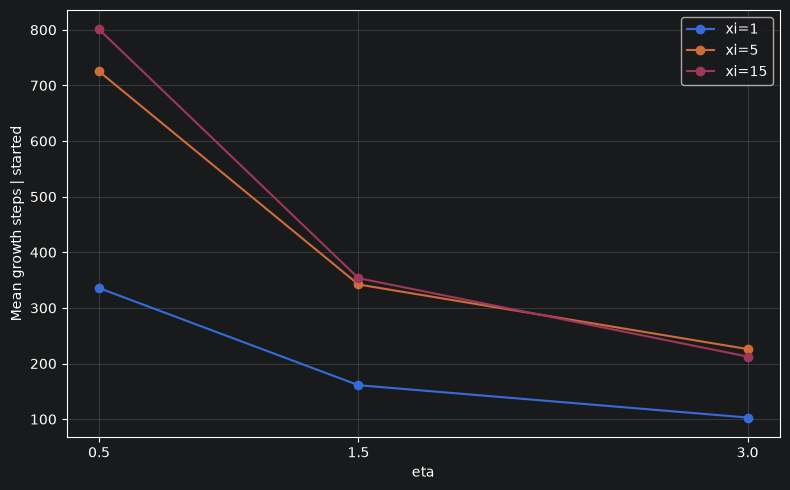

In [39]:
plt.figure(figsize=(8, 5))

for xi in correlation_lengths:
    subset = xi_eta_steps[
        xi_eta_steps[
            "correlation_length"
        ] == xi
    ]

    plt.plot(
        subset["eta"],
        subset["mean_steps"],
        marker="o",
        label=f"xi={xi}",
    )

plt.xlabel("eta")
plt.ylabel("Mean growth steps | started")
plt.xticks(eta_values)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### Взаимодействие correlation length и eta: кинетика роста

Для числа шагов наблюдается выраженное совместное влияние `correlation_length` и `eta`.

При всех значениях $\xi$ увеличение

$$
\eta: 0.5 \rightarrow 3.0
$$

резко уменьшает среднее число шагов.

При этом влияние correlation length особенно велико при малой селективности роста.

При

$$
\eta=0.5
$$

среднее число шагов увеличивается примерно от

$$
335
$$

для

$$
\xi=1
$$

до

$$
800
$$

для

$$
\xi=15.
$$

При

$$
\eta=3
$$

различия становятся значительно меньше.

Следовательно, высокая селективность выбора следующей клетки частично подавляет влияние пространственного масштаба disorder на длину траектории.

Таким образом, взаимодействие $\xi\times\eta$ слабое для вероятности пробоя, но выраженное для кинетики роста и потенциально особенно важно для морфологии электрического дерева.

In [44]:
def interaction_effect(
    df,
    parameter_a,
    parameter_b,
    value_a_low,
    value_a_high,
    value_b_low,
    value_b_high,
):
    table = (
        df[
            df[parameter_a].isin(
                [value_a_low, value_a_high]
            )
            & df[parameter_b].isin(
                [value_b_low, value_b_high]
            )
        ]
        .groupby(
            [
                parameter_a,
                parameter_b,
            ]
        )
        ["breakdown"]
        .mean()
        .unstack()
    )

    effect_low_b = (
        table.loc[
            value_a_high,
            value_b_low,
        ]
        - table.loc[
            value_a_low,
            value_b_low,
        ]
    )

    effect_high_b = (
        table.loc[
            value_a_high,
            value_b_high,
        ]
        - table.loc[
            value_a_low,
            value_b_high,
        ]
    )

    interaction = (
        effect_high_b
        - effect_low_b
    )

    return interaction

In [45]:
interaction_summary = pd.DataFrame(
    [
        {
            "interaction": "k × xi",
            "effect": interaction_effect(
                results_df,
                "k",
                "correlation_length",
                2.0,
                15.0,
                1,
                15,
            ),
        },
        {
            "interaction": "k × eta",
            "effect": interaction_effect(
                results_df,
                "k",
                "eta",
                2.0,
                15.0,
                0.5,
                3.0,
            ),
        },
        {
            "interaction": "k × Ebd",
            "effect": interaction_effect(
                results_df,
                "k",
                "mean_breakdown_field",
                2.0,
                15.0,
                2.7,
                3.3,
            ),
        },
        {
            "interaction": "xi × eta",
            "effect": interaction_effect(
                results_df,
                "correlation_length",
                "eta",
                1,
                15,
                0.5,
                3.0,
            ),
        },
        {
            "interaction": "xi × Ebd",
            "effect": interaction_effect(
                results_df,
                "correlation_length",
                "mean_breakdown_field",
                1,
                15,
                2.7,
                3.3,
            ),
        },
        {
            "interaction": "eta × Ebd",
            "effect": interaction_effect(
                results_df,
                "eta",
                "mean_breakdown_field",
                0.5,
                3.0,
                2.7,
                3.3,
            ),
        },
    ]
)

interaction_summary

,interaction,effect
0,k × xi,-0.797778
1,k × eta,0.008889
2,k × Ebd,-0.733333
3,xi × eta,0.002222
4,xi × Ebd,0.073333
5,eta × Ebd,-0.006667


In [46]:
material_joint = (
    results_df
    .groupby(
        [
            "disorder_seed",
            "k",
            "correlation_length",
            "eta",
            "mean_breakdown_field",
        ]
    )
    ["breakdown"]
    .mean()
    .reset_index()
)

material_joint.head()

,disorder_seed,k,correlation_length,eta,mean_breakdown_field,breakdown
0,0,2.0,1,0.5,2.7,0.2
1,0,2.0,1,0.5,3.0,0.0
2,0,2.0,1,0.5,3.3,0.0
3,0,2.0,1,1.5,2.7,0.4
4,0,2.0,1,1.5,3.0,0.4


In [47]:
interaction_specs = [
    (
        "k × xi",
        "k",
        "correlation_length",
        2.0,
        15.0,
        1,
        15,
    ),
    (
        "k × eta",
        "k",
        "eta",
        2.0,
        15.0,
        0.5,
        3.0,
    ),
    (
        "k × Ebd",
        "k",
        "mean_breakdown_field",
        2.0,
        15.0,
        2.7,
        3.3,
    ),
    (
        "xi × eta",
        "correlation_length",
        "eta",
        1,
        15,
        0.5,
        3.0,
    ),
    (
        "xi × Ebd",
        "correlation_length",
        "mean_breakdown_field",
        1,
        15,
        2.7,
        3.3,
    ),
    (
        "eta × Ebd",
        "eta",
        "mean_breakdown_field",
        0.5,
        3.0,
        2.7,
        3.3,
    ),
]

In [48]:
seed_interactions = {}

for (
    name,
    parameter_a,
    parameter_b,
    a_low,
    a_high,
    b_low,
    b_high,
) in interaction_specs:

    effects = []

    for disorder_seed, group in material_joint.groupby(
        "disorder_seed"
    ):
        effect = interaction_effect(
            group,
            parameter_a,
            parameter_b,
            a_low,
            a_high,
            b_low,
            b_high,
        )

        effects.append(effect)

    seed_interactions[name] = np.array(
        effects
    )

In [49]:
rng = np.random.default_rng(42)

n_bootstrap = 10_000

bootstrap_records = []

for name, effects in seed_interactions.items():

    bootstrap_values = np.empty(
        n_bootstrap
    )

    for i in range(n_bootstrap):
        sample = rng.choice(
            effects,
            size=len(effects),
            replace=True,
        )

        bootstrap_values[i] = (
            sample.mean()
        )

    effect = effects.mean()

    ci_low = np.quantile(
        bootstrap_values,
        0.025,
    )

    ci_high = np.quantile(
        bootstrap_values,
        0.975,
    )

    bootstrap_records.append(
        {
            "interaction": name,
            "effect": effect,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "ci_excludes_zero": (
                (ci_low > 0)
                or (ci_high < 0)
            ),
        }
    )

interaction_bootstrap = pd.DataFrame(
    bootstrap_records
)

interaction_bootstrap

,interaction,effect,ci_low,ci_high,ci_excludes_zero
0,k × xi,-0.797778,-0.931111,-0.653333,True
1,k × eta,0.008889,-0.004444,0.022222,False
2,k × Ebd,-0.733333,-0.873389,-0.571111,True
3,xi × eta,0.002222,-0.013333,0.017778,False
4,xi × Ebd,0.073333,-0.160000,0.280000,False
5,eta × Ebd,-0.006667,-0.024444,0.011111,False


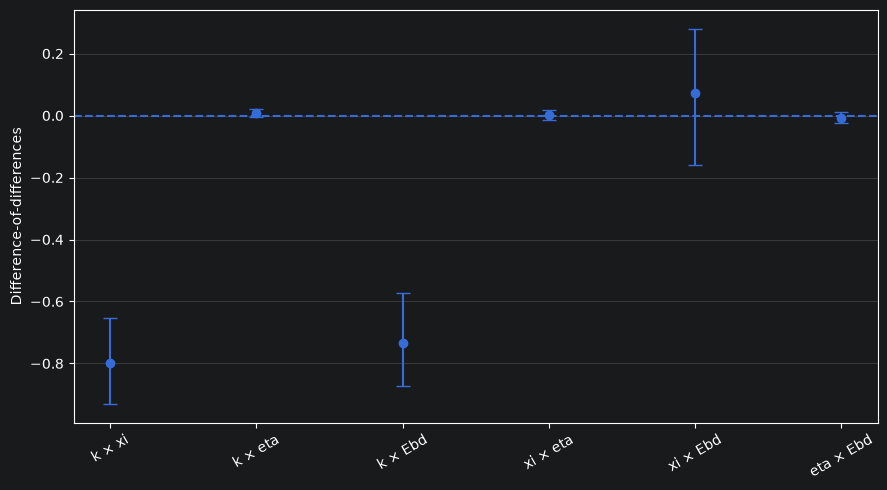

In [50]:
plt.figure(figsize=(9, 5))

x = np.arange(
    len(interaction_bootstrap)
)

effects = interaction_bootstrap[
    "effect"
].to_numpy()

lower = (
    effects
    - interaction_bootstrap[
        "ci_low"
    ].to_numpy()
)

upper = (
    interaction_bootstrap[
        "ci_high"
    ].to_numpy()
    - effects
)

plt.errorbar(
    x,
    effects,
    yerr=np.vstack(
        [lower, upper]
    ),
    fmt="o",
    capsize=5,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xticks(
    x,
    interaction_bootstrap[
        "interaction"
    ],
    rotation=30,
)

plt.ylabel(
    "Difference-of-differences"
)

plt.grid(
    alpha=0.3,
    axis="y",
)

plt.tight_layout()
plt.show()

In [51]:
parameter_info = {
    "k": {
        "label": "k",
        "values": k_values,
    },
    "correlation_length": {
        "label": "xi",
        "values": correlation_lengths,
    },
    "eta": {
        "label": "eta",
        "values": eta_values,
    },
    "mean_breakdown_field": {
        "label": "Ebd",
        "values": threshold_values,
    },
}

parameter_names = list(
    parameter_info.keys()
)

In [52]:
def build_pair_matrix(
    df,
    parameter_y,
    parameter_x,
    value_column,
):
    table = (
        df
        .groupby(
            [
                parameter_y,
                parameter_x,
            ]
        )[value_column]
        .mean()
        .unstack(parameter_x)
    )

    y_values = parameter_info[
        parameter_y
    ]["values"]

    x_values = parameter_info[
        parameter_x
    ]["values"]

    table = table.reindex(
        index=y_values,
        columns=x_values,
    )

    return table

In [53]:
started_df = (
    results_df[
        results_df["started"]
    ]
    .copy()
)

steps_min = (
    started_df["steps"]
    .groupby(
        [
            started_df["k"],
            started_df["correlation_length"],
        ]
    )
    .mean()
    .min()
)

steps_max = (
    started_df
    .groupby(
        [
            "k",
            "correlation_length",
            "eta",
            "mean_breakdown_field",
        ]
    )["steps"]
    .mean()
    .max()
)

print(
    "Mean steps scale:",
    steps_min,
    steps_max,
)

Mean steps scale: 89.42 995.08


In [55]:
steps_pair_means = []

for i, parameter_y in enumerate(
    parameter_names
):
    for j, parameter_x in enumerate(
        parameter_names
    ):
        if i <= j:
            continue

        table = build_pair_matrix(
            started_df,
            parameter_y,
            parameter_x,
            "steps",
        )

        steps_pair_means.extend(
            table.to_numpy().ravel()
        )

steps_pair_means = np.array(
    steps_pair_means
)

steps_vmin = np.nanmin(
    steps_pair_means
)

steps_vmax = np.nanmax(
    steps_pair_means
)

print(
    "Steps range:",
    steps_vmin,
    steps_vmax,
)

Steps range: 46.59166666666667 800.704347826087


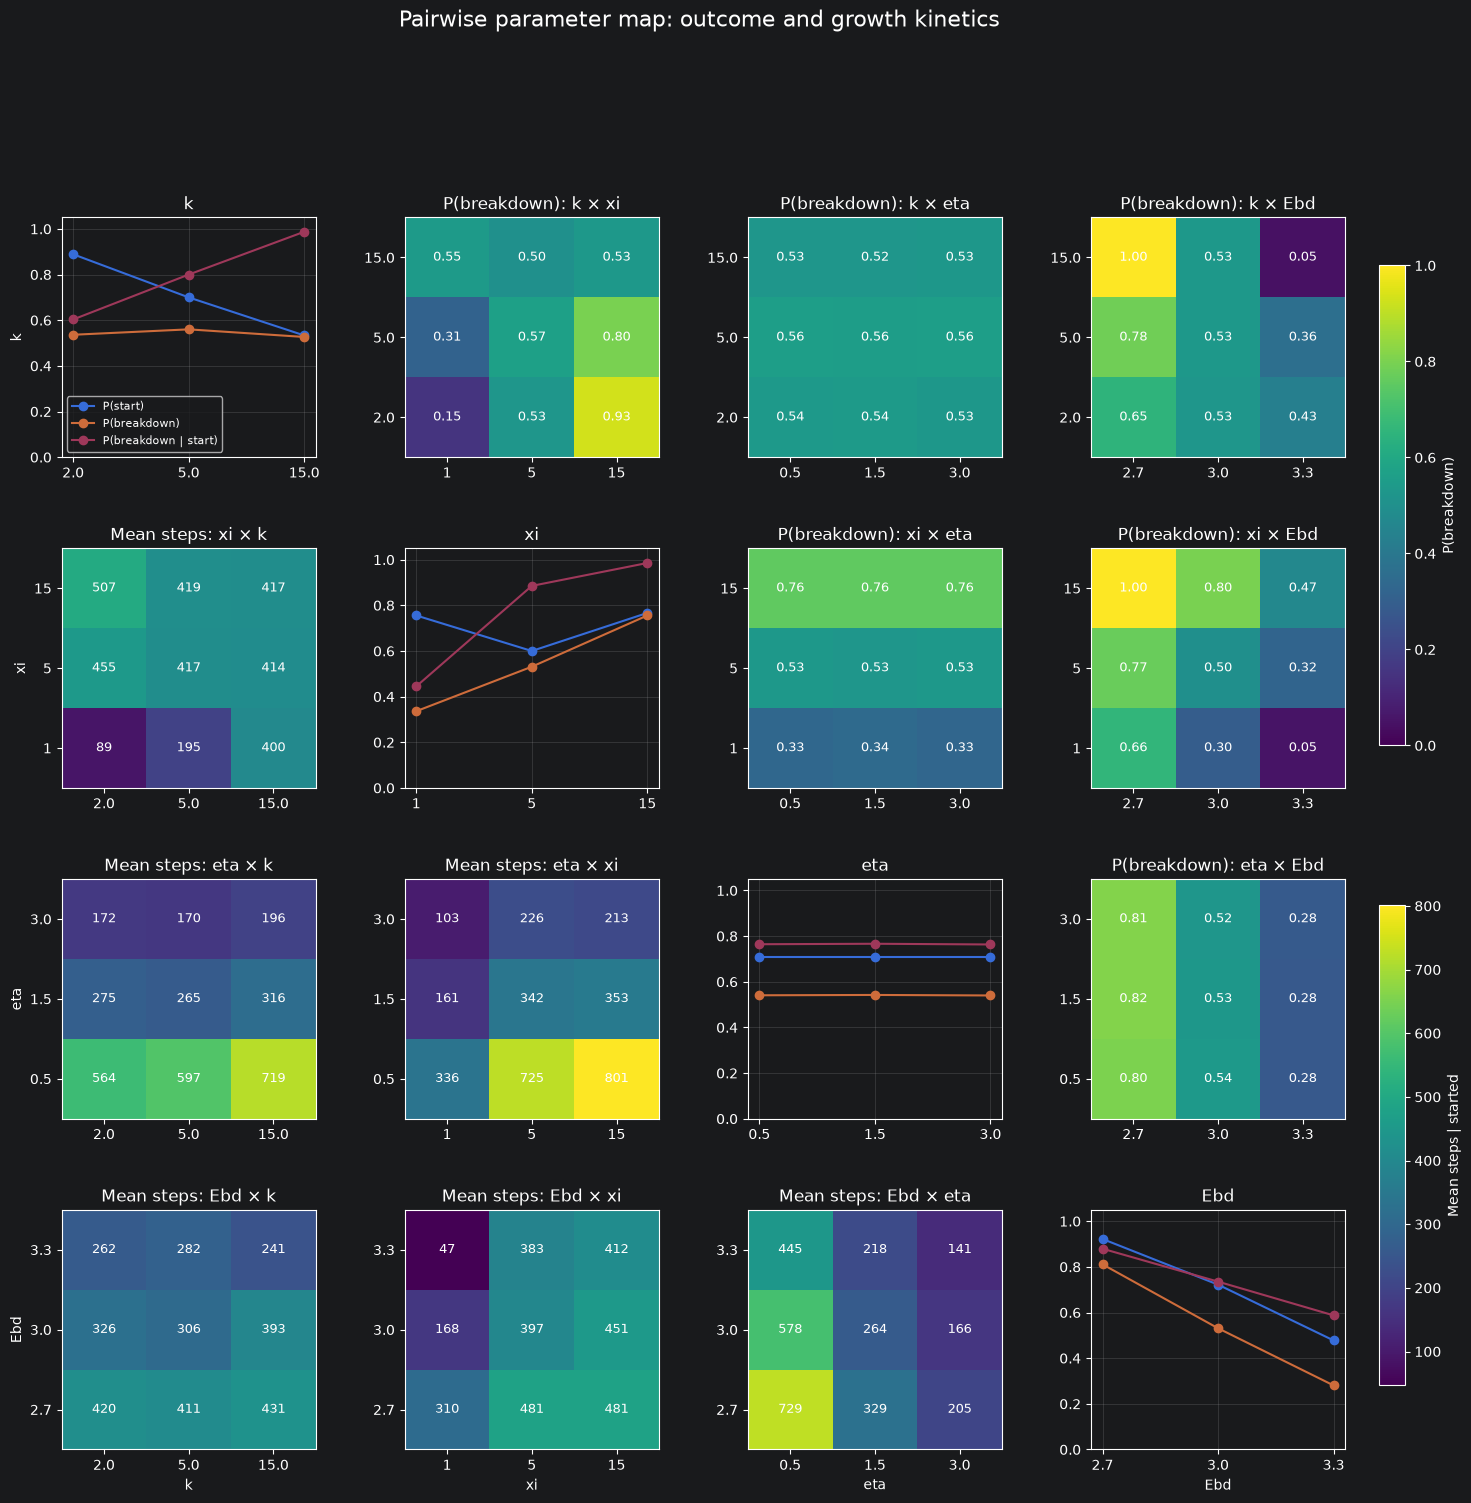

In [56]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(17, 16),
)

breakdown_image = None
steps_image = None

for i, parameter_y in enumerate(
    parameter_names
):
    for j, parameter_x in enumerate(
        parameter_names
    ):

        ax = axes[i, j]

        label_y = parameter_info[
            parameter_y
        ]["label"]

        label_x = parameter_info[
            parameter_x
        ]["label"]

        values_y = parameter_info[
            parameter_y
        ]["values"]

        values_x = parameter_info[
            parameter_x
        ]["values"]

        if i == j:
            marginal = (
                results_df
                .groupby(parameter_x)
                .agg(
                    p_start=(
                        "started",
                        "mean",
                    ),
                    p_breakdown=(
                        "breakdown",
                        "mean",
                    ),
                )
                .reindex(values_x)
            )

            conditional = (
                results_df[
                    results_df["started"]
                ]
                .groupby(parameter_x)[
                    "breakdown"
                ]
                .mean()
                .reindex(values_x)
            )

            ax.plot(
                range(len(values_x)),
                marginal["p_start"],
                marker="o",
                label="P(start)",
            )

            ax.plot(
                range(len(values_x)),
                marginal["p_breakdown"],
                marker="o",
                label="P(breakdown)",
            )

            ax.plot(
                range(len(values_x)),
                conditional,
                marker="o",
                label="P(breakdown | start)",
            )

            ax.set_ylim(
                0,
                1.05,
            )

            ax.set_xticks(
                range(len(values_x))
            )

            ax.set_xticklabels(
                values_x
            )

            ax.set_title(
                label_x
            )

            ax.grid(
                alpha=0.25
            )

            if i == 0:
                ax.legend(
                    fontsize=8
                )

        elif i < j:
            table = build_pair_matrix(
                results_df,
                parameter_y,
                parameter_x,
                "breakdown",
            )

            breakdown_image = ax.imshow(
                table.to_numpy(),
                origin="lower",
                aspect="auto",
                vmin=0,
                vmax=1,
            )

            ax.set_xticks(
                range(len(values_x))
            )

            ax.set_xticklabels(
                values_x
            )

            ax.set_yticks(
                range(len(values_y))
            )

            ax.set_yticklabels(
                values_y
            )

            for row in range(
                len(values_y)
            ):
                for col in range(
                    len(values_x)
                ):
                    value = table.iloc[
                        row,
                        col,
                    ]

                    ax.text(
                        col,
                        row,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                        fontsize=9,
                    )

            ax.set_title(
                f"P(breakdown): "
                f"{label_y} × {label_x}"
            )

        else:
            table = build_pair_matrix(
                started_df,
                parameter_y,
                parameter_x,
                "steps",
            )

            steps_image = ax.imshow(
                table.to_numpy(),
                origin="lower",
                aspect="auto",
                vmin=steps_vmin,
                vmax=steps_vmax,
            )

            ax.set_xticks(
                range(len(values_x))
            )

            ax.set_xticklabels(
                values_x
            )

            ax.set_yticks(
                range(len(values_y))
            )

            ax.set_yticklabels(
                values_y
            )

            for row in range(
                len(values_y)
            ):
                for col in range(
                    len(values_x)
                ):
                    value = table.iloc[
                        row,
                        col,
                    ]

                    ax.text(
                        col,
                        row,
                        f"{value:.0f}",
                        ha="center",
                        va="center",
                        fontsize=9,
                    )

            ax.set_title(
                f"Mean steps: "
                f"{label_y} × {label_x}"
            )

        if i == 3:
            ax.set_xlabel(
                label_x
            )

        if j == 0:
            ax.set_ylabel(
                label_y
            )

fig.suptitle(
    "Pairwise parameter map: "
    "outcome and growth kinetics",
    fontsize=16,
    y=1.01,
)

fig.subplots_adjust(
    right=0.88,
    hspace=0.38,
    wspace=0.35,
)

cax_breakdown = fig.add_axes(
    [
        0.90,
        0.55,
        0.015,
        0.30,
    ]
)

fig.colorbar(
    breakdown_image,
    cax=cax_breakdown,
    label="P(breakdown)",
)

cax_steps = fig.add_axes(
    [
        0.90,
        0.15,
        0.015,
        0.30,
    ]
)

fig.colorbar(
    steps_image,
    cax=cax_steps,
    label="Mean steps | started",
)

plt.show()

## Итог joint parameter sweep

Совместный анализ параметров показал, что макроскопический исход пробоя определяется не только отдельными физическими параметрами, но и их взаимодействиями.

Наиболее сильные взаимодействия для вероятности полного пробоя обнаружены для

$$
k \times \xi
$$

и

$$
k \times E_{bd}.
$$

Для них difference-of-differences составляет приблизительно

$$
I_{k,\xi}\approx-0.80,
$$

$$
I_{k,E_{bd}}\approx-0.74,
$$

а 95% cluster-bootstrap confidence intervals не пересекают ноль.

Это означает, что влияние степени неоднородности материала существенно зависит как от пространственного масштаба disorder, так и от базового порога пробоя.

Напротив, взаимодействия

$$
k\times\eta,
\qquad
\xi\times\eta,
\qquad
\eta\times E_{bd}
$$

имеют величину, близкую к нулю для вероятности полного пробоя.

Следовательно, параметр `eta` практически не участвует в формировании макроскопического outcome, хотя предыдущий анализ показал его сильное влияние на число шагов и кинетику роста.

Для пары

$$
\xi\times E_{bd}
$$

центральная оценка interaction невелика, а bootstrap confidence interval пересекает ноль, поэтому устойчивого взаимодействия на уровне вероятности полного пробоя в текущем ensemble не обнаружено.

Таким образом, параметры модели разделяются на две функциональные группы:

$$
(k,\xi,E_{bd})
\rightarrow
\text{initiation and macroscopic breakdown},
$$

тогда как

$$
\eta
\rightarrow
\text{kinetics and morphology}.
$$

Особенно важным является взаимодействие

$$
k\times\xi,
$$

показывающее, что амплитуду неоднородности и её пространственную структуру нельзя рассматривать независимо.

### Ограничение статистической оценки

Bootstrap выполнялся по независимым реализациям материала (`disorder_seed`), поэтому внутренняя зависимость стохастических траекторий одного материала сохранялась.

В pilot joint sweep использовано 10 независимых disorder-реализаций на конфигурацию. Этого достаточно для выявления крупных эффектов, однако более слабые interactions перед финальной публикацией следует перепроверить на увеличенном ensemble.

## Выводы для генерации research dataset

Joint parameter sweep показал, что равномерная независимая генерация параметров не является оптимальной стратегией для будущего датасета.

Во-первых, макроскопический исход определяется выраженными взаимодействиями параметров.

Наиболее сильными являются

$$
k\times\xi
$$

и

$$
k\times E_{bd}.
$$

Следовательно, значения `weibull_shape`, `correlation_length` и `mean_breakdown_field`
нельзя независимо семплировать и затем интерпретировать только через их отдельные эффекты.

Особенно важна плоскость

$$
(k,\xi),
$$

поскольку одинаковая амплитуда disorder может приводить к противоположному поведению в зависимости от пространственной связности слабых областей.

Во-вторых, параметр `eta` практически не влияет на вероятность полного пробоя, однако оказывает очень сильное влияние на число шагов и динамику роста.

Следовательно, конфигурации с различными `eta` необходимо обязательно сохранять в датасете даже тогда, когда их макроскопический outcome одинаков.

Именно морфология канала должна содержать основную информацию об этом параметре.

Для массовой генерации датасета следует использовать смешанную стратегию sampling.

Основная доля объектов должна генерироваться в переходной области, где

$$
0.2 \lesssim P(breakdown) \lesssim 0.8,
$$

поскольку именно здесь stochastic outcome содержит наибольшую информацию.

При этом необходимо сохранить часть крайних режимов

$$
P(breakdown)\approx0
$$

и

$$
P(breakdown)\approx1
$$

как физические controls и для покрытия границ параметрического пространства.

Порог пробоя следует семплировать плотнее в исследованной переходной области. Вместо только трёх значений

$$
2.7,\ 3.0,\ 3.3
$$

для большого датасета целесообразно использовать, например,

$$
E_{bd}\in
\{2.7,\ 2.85,\ 3.0,\ 3.15,\ 3.3\},
$$

а небольшое число объектов дополнительно генерировать в более крайних режимах.

Параметры

$$
k\in\{2,5,15\},
\qquad
\xi\in\{1,5,15\},
\qquad
\eta\in\{0.5,1.5,3\}
$$

следует сохранить как минимум на первом этапе, поскольку они представляют физически существенно различные режимы.

Каждая физическая конфигурация должна включать несколько независимых реализаций материала и несколько стохастических траекторий:

$$
\text{physical configuration}
\times
\text{disorder realization}
\times
\text{growth trajectory}.
$$

`disorder_seed` должен рассматриваться как идентификатор независимого материала, а не как числовой ML-признак.

При разбиении датасета необходимо использовать group split по реализации disorder, чтобы одна и та же структура материала не попадала одновременно в train и test.

Таким образом, будущий датасет должен быть не равномерной таблицей случайных симуляций, а контролируемым hierarchical dataset, специально покрывающим:

1. переходную область пробоя;
2. сильные взаимодействия $k\times\xi$ и $k\times E_{bd}$;
3. различные кинетические режимы `eta`;
4. крайние физические режимы как controls;
5. отдельные комбинации параметров для проверки generalization.